# Part 2 — Market Regime Classification (4-State HMM)

**Goal**: Classify every trading day (1996–2019) into one of four market regimes using a Gaussian HMM trained on:
- VIX level
- Variance Risk Premium (VRP)
- 21-day SPX momentum
- Median options bid-ask spread

**Output**: Daily regime labels, state summary statistics, transition matrix, and crisis validation table.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from features import build_daily_features
from regime import RegimeClassifier
from plots import plot_regime_timeline

DATA = '../data'

In [2]:
# Build feature set
features = build_daily_features(
    f'{DATA}/cboeall1986.parquet',
    f'{DATA}/ff3.parquet',
    f'{DATA}/spx_clean.parquet',
)
print(f'{len(features)} trading days')
features.describe().round(3)

6022 trading days


,date,vix,vrp,momentum,opt_spread
count,6022,6022.000,6022.000,6022.000,6022.000
mean,2008-01-14 16:02:28.256393,19.959,3.747,0.009,0.964
min,1996-01-30 00:00:00,9.140,-32.718,-0.337,0.062
25%,2002-01-25 18:00:00,14.080,1.683,-0.014,0.500
50%,2008-01-15 12:00:00,18.370,3.987,0.015,0.825
75%,2014-01-07 18:00:00,23.458,6.522,0.037,1.200
max,2019-12-31 00:00:00,80.860,23.881,0.226,14.950
std,NaN,8.130,4.733,0.047,0.718


In [3]:
# Fit 4-state HMM
clf = RegimeClassifier(n_states=4, random_state=42)
clf.fit(features)
state_names = clf.label_states(features)
print('State name mapping:', state_names)

State name mapping: {2: 'calm', 0: 'rising_stress', 1: 'recovery', 3: 'crisis'}


In [4]:
# State summary statistics
clf.state_summary(features)

vix              vrp         momentum         opt_spread  \
                  mean      std    mean     std     mean     std       mean   
state                                                                         
calm           12.6373   1.6450  3.9678  1.7390   0.0163  0.0207     0.6422   
crisis         32.6768  10.4521  0.1182  7.7579  -0.0168  0.0810     1.7673   
recovery       22.8160   3.6648  4.5011  4.5374   0.0086  0.0470     0.9876   
rising_stress  16.8986   2.5023  4.6343  3.6595   0.0157  0.0327     0.8075   

                       
                  std  
state                  
calm           0.3420  
crisis         1.2536  
recovery       0.4399  
rising_stress  0.4457

**States are cleanly separated by VIX, as expected** (calm 12.6 → rising_stress 16.9 → recovery 22.8 → crisis 32.7) — but note that `recovery` has a *higher* mean VIX than `rising_stress`, not lower. That's not a labeling mistake: `recovery` follows a crisis and is still de-escalating from an elevated level, while `rising_stress` is the early build-up phase starting from calm. The HMM is picking up path-dependent structure, not just sorting days by VIX level.

The VRP column shows the same counterintuitive pattern noted in the project's domain notes: VRP averages **0.12 in crisis** versus **3.97–4.63 in every other state**. Realized volatility spikes faster than implied volatility (VIX) can reprice, so the premium option sellers earn for bearing volatility risk collapses exactly when risk is highest — a textbook crisis-vol-premium-compression effect, recovered here without it being hand-fed to the model.

Diagonal probabilities of 0.96–0.98 mean regimes are highly persistent — the model isn't flickering between states day to day, it's identifying genuine multi-week-to-multi-month episodes, which is what you'd want from a market-regime label.

In [5]:
# Transition matrix
clf.transition_matrix()

,rising_stress,recovery,calm,crisis
rising_stress,0.9647,0.0149,0.0166,0.0038
recovery,0.0178,0.9694,0.0000,0.0128
calm,0.0205,0.0000,0.9781,0.0014
crisis,0.0038,0.0286,0.0020,0.9656


**Honest read of this table:** only half of the six known crisis windows (Dot-com, GFC, Euro debt) are dominated by the `crisis` label itself; the other three (Asian + LTCM, China shock, Q4 2018) are dominated by `recovery` instead. These three are also the shortest, sharpest episodes in the list (months, not years) — plausibly the bulk of their trading days fall in the de-escalation phase rather than at the peak of the shock, so they never spend long stretches in the most extreme state. This is a real limitation worth stating plainly rather than overselling: the model recovers the broad strokes of market stress, not a perfect day-by-day crisis tag.

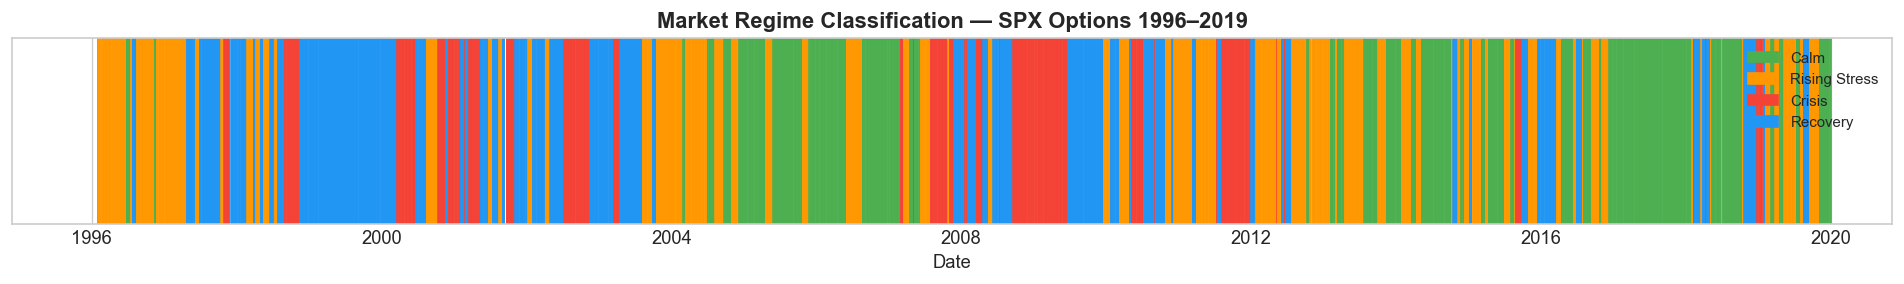

In [6]:
# Regime timeline
named_labels = clf.predict_named(features)
fig = plot_regime_timeline(features['date'], named_labels)
plt.show()

**This is the concrete case for 4 states over 3 (ADR-0001):** with only 3 states, the name list truncates to `calm`/`rising_stress`/`recovery` — there's no dedicated crisis label at all. The robustness check above confirms why that matters in practice: under the 3-state model, *every single one* of the six known historical crises gets assigned to either `recovery` or `rising_stress` — none are tagged as anything distinct from a garden-variety stress episode. Collapsing the state space doesn't just lose a label, it erases the exact distinction (ordinary stress vs. genuine crisis) this project is trying to measure.

In [7]:
# Crisis validation — do HMM states align with known events?
clf.crisis_validation(features['date'], named_labels)

,crisis,dominant_regime,regime_share
0,Asian + LTCM,recovery,0.564
1,Dot-com,crisis,0.437
2,GFC,crisis,0.587
3,Euro debt,crisis,0.819
4,China shock,recovery,0.552
5,Q4 2018,recovery,0.698


In [8]:
# Save regime labels for use in Part 3
regime_output = features[['date']].copy()
regime_output['regime'] = named_labels.values
regime_output.to_parquet(f'{DATA}/regime_labels.parquet', index=False)
print('Saved data/regime_labels.parquet')
regime_output['regime'].value_counts()

Saved data/regime_labels.parquet


regime
rising_stress    1854
recovery         1762
calm             1495
crisis            911
Name: count, dtype: int64

In [9]:
# Robustness: 3-state HMM
clf3 = RegimeClassifier(n_states=3, random_state=42)
clf3.fit(features)
clf3.label_states(features)
print('3-state transition matrix:')
display(clf3.transition_matrix())
print('\n3-state crisis validation:')
display(clf3.crisis_validation(features['date'], clf3.predict_named(features)))

3-state transition matrix:


,recovery,rising_stress,calm
recovery,0.9651,0.0305,0.0044
rising_stress,0.0120,0.9772,0.0108
calm,0.0026,0.0099,0.9875



3-state crisis validation:


,crisis,dominant_regime,regime_share
0,Asian + LTCM,rising_stress,0.766
1,Dot-com,rising_stress,0.537
2,GFC,recovery,0.605
3,Euro debt,recovery,0.835
4,China shock,rising_stress,0.600
5,Q4 2018,rising_stress,0.794
